# AI-Driven Urban Traffic Optimization Prototype
**Christopher Paul**

This notebook presents a proof-of-concept for short-term urban traffic forecasting using a graph-based deep learning approach. It models a small network of intersections as a graph, simulates realistic traffic behavior, and predicts congestion fifteen minutes ahead.

The project is designed to demonstrate the technical feasibility of graph neural networks for traffic operations and smart-city decision support. It focuses on whether a lightweight graph model can outperform a simple baseline and capture the spatial relationships that make traffic forecasting difficult with traditional approaches.


In [1]:
import numpy as np
import torch
from torch import nn

torch.manual_seed(42)
np.random.seed(42)

print('PyTorch version:', torch.__version__)

PyTorch version: 2.10.0+cpu


## 1. Traffic network as a graph
I start with a small road network that behaves like a city corridor. Each node is an intersection, and each edge is a road segment between intersections. This keeps the prototype light but still lets me show why a graph model makes sense.

In [2]:
# number of intersections
num_nodes = 12

# edges of a simple 3x4 grid (undirected)
edges = [
    (0,1),(1,2),(2,3),
    (4,5),(5,6),(6,7),
    (8,9),(9,10),(10,11),
    (0,4),(4,8),
    (1,5),(5,9),
    (2,6),(6,10),
    (3,7),(7,11)
]

A = torch.zeros(num_nodes, num_nodes)
for i, j in edges:
    A[i, j] = 1.0
    A[j, i] = 1.0

# add self loops and normalize (GCN style)
A_hat = A + torch.eye(num_nodes)
deg = A_hat.sum(1)
D_inv_sqrt = torch.diag(1.0 / torch.sqrt(deg))
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

print('Adjacency shape:', A.shape)

Adjacency shape: torch.Size([12, 12])


## 2. Simulated traffic data
In a real deployment, this model would plug into DOT feeds, loop detectors, or connected‑vehicle data. For the prototype, I simulate traffic volumes with a daily pattern, rush‑hour spikes, neighbor influence, and random incidents that cause short term congestion. This is enough to show that the model can learn useful structure from the data.

In [3]:
T = 500  # time steps (for example 500 x 15 minutes ≈ 5 days)
minutes_per_step = 15
steps_per_day = int(24 * 60 / minutes_per_step)

time = np.arange(T)
tod = time % steps_per_day
tod_sin = np.sin(2 * np.pi * tod / steps_per_day).astype(np.float32)
tod_cos = np.cos(2 * np.pi * tod / steps_per_day).astype(np.float32)

volumes = np.zeros((T, num_nodes), dtype=np.float32)
incidents = np.zeros((T, num_nodes), dtype=np.float32)

# initial traffic at t = 0
volumes[0] = 20 + 5 * np.random.randn(num_nodes)

for t in range(1, T):
    rush_am = (tod[t] >= 28) & (tod[t] <= 40)   # morning rush
    rush_pm = (tod[t] >= 70) & (tod[t] <= 90)   # evening rush
    rush_factor = 1.0 + 0.8 * rush_am + 1.0 * rush_pm

    prev = volumes[t - 1]
    neighbor_mean = (A.numpy() @ prev) / np.clip(A.numpy().sum(1), 1, None)

    base = 15 + 0.6 * prev + 0.3 * neighbor_mean \
           + 10 * np.sin(2 * np.pi * t / steps_per_day)

    noise = np.random.randn(num_nodes) * 3.0
    v = base * rush_factor + noise

    # random incidents that spike congestion
    if np.random.rand() < 0.05:
        k = np.random.randint(0, num_nodes)
        v[k] += 40
        incidents[t, k] = 1.0

    volumes[t] = np.clip(v, 0, None)

print('Simulated traffic series shape:', volumes.shape)

Simulated traffic series shape: (500, 12)


## 3. Building a supervised dataset
The task is to forecast congestion one step ahead at every intersection. I use the last four time steps for each node, plus time of day and an incident flag, to predict the next traffic volume. This gives a three dimensional tensor shaped as batch by node by feature.

In [4]:
lookback = 4
F = lookback + 2 + 1  # four lagged volumes, sin, cos, incident flag
num_samples = T - lookback - 1

X = np.zeros((num_samples, num_nodes, F), dtype=np.float32)
y = np.zeros((num_samples, num_nodes), dtype=np.float32)

for idx in range(num_samples):
    t = lookback + idx
    for n in range(num_nodes):
        hist = volumes[t - lookback:t, n]
        feat = np.concatenate([
            hist,
            [tod_sin[t], tod_cos[t]],
            [incidents[t - 1, n]]
        ])
        X[idx, n, :] = feat
    y[idx] = volumes[t]

# simple scaling so the model has an easier job
y_scale = y.mean()
X[:, :, :lookback] /= y_scale
y /= y_scale

train_size = int(num_samples * 0.8)
X_train = torch.tensor(X[:train_size])
y_train = torch.tensor(y[:train_size])
X_test = torch.tensor(X[train_size:])
y_test = torch.tensor(y[train_size:])

print('Train samples:', X_train.shape[0])
print('Test samples:', X_test.shape[0])

Train samples: 396
Test samples: 99


## 4. Graph‑based forecasting model
To match the story from the slides, I use a simple graph neural network. Each layer mixes information from an intersection and its neighbors using the normalized adjacency matrix. The model predicts the next step of traffic volume at every node in one shot.

In [5]:
class SimpleGNNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.self_lin = nn.Linear(in_dim, out_dim)
        self.neigh_lin = nn.Linear(in_dim, out_dim)

    def forward(self, X, A_norm):
        # X: [batch, nodes, features]
        neigh = torch.matmul(A_norm, X)
        return torch.relu(self.self_lin(X) + self.neigh_lin(neigh))


class TrafficGNN(nn.Module):
    def __init__(self, in_dim, hidden_dim=32):
        super().__init__()
        self.gnn1 = SimpleGNNLayer(in_dim, hidden_dim)
        self.gnn2 = SimpleGNNLayer(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, X, A_norm):
        h = self.gnn1(X, A_norm)
        h = self.gnn2(h, A_norm)
        out = self.out(h).squeeze(-1)
        return out


model = TrafficGNN(F, hidden_dim=32)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

sum(p.numel() for p in model.parameters() if p.requires_grad)

2657

## 5. Training loop
I train for a small number of epochs just to get a sensible fit. The focus here is not hyperparameter tuning. The real point is to show that the graph model learns patterns that a simple rule cannot see.

In [6]:
num_epochs = 25

for epoch in range(1, num_epochs + 1):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train, A_norm)
    loss = loss_fn(pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        pred_test = model(X_test, A_norm)
        val_loss = loss_fn(pred_test, y_test).item()

    if epoch == 1 or epoch % 5 == 0:
        print(f'Epoch {epoch:02d} | train MSE {loss.item():.4f} | val MSE {val_loss:.4f}')

# keep predictions for evaluation and plots
model.eval()
with torch.no_grad():
    preds = model(X_test, A_norm)

Epoch 01 | train MSE 0.0020 | val MSE 173.7019
Epoch 05 | train MSE 0.0007 | val MSE 165.4016
Epoch 10 | train MSE 0.0004 | val MSE 165.3410
Epoch 15 | train MSE 0.0001 | val MSE 162.0668
Epoch 20 | train MSE 0.0001 | val MSE 164.4597
Epoch 25 | train MSE 0.0001 | val MSE 166.3906


## 6. Evaluation versus a naïve baseline
As a sanity check, I compare the model to a very simple baseline that just repeats the last observed volume. If the model cannot beat that, the idea is not compelling. I report mean absolute error for both approaches and show the relative improvement.

In [7]:
# baseline uses the most recent lagged volume
last_lag = X_test[:, :, 3]
baseline = last_lag

mae_model = (preds - y_test).abs().mean().item()
mae_baseline = (baseline - y_test).abs().mean().item()

print('Model MAE:   ', round(mae_model, 4))
print('Baseline MAE:', round(mae_baseline, 4))
improvement = (mae_baseline - mae_model) / mae_baseline * 100
print('Relative improvement vs baseline: {:.1f}%'.format(improvement))

# simple decision layer for the last test step
with torch.no_grad():
    last_pred = preds[-1] * y_scale
    last_true = y_test[-1] * y_scale

congestion_scores = last_pred.numpy()
top_k = 3
top_nodes = congestion_scores.argsort()[-top_k:][::-1]

print('\nTop intersections to optimize at the next interval:')
for rank, node_id in enumerate(top_nodes, start=1):
    print(
        f'{rank}. Node {node_id} | predicted volume ≈ {congestion_scores[node_id]:.1f} ' \
        f'(actual {last_true[node_id].item():.1f})'
    )

Model MAE:    5.7233
Baseline MAE: 0.9116
Relative improvement vs baseline: -527.8%

Top intersections to optimize at the next interval:
1. Node 11 | predicted volume ≈ -16209716569475854851465281536.0 (actual 137032629458216996446245224448.0)
2. Node 0 | predicted volume ≈ -16209717750067475568876584960.0 (actual 137032629458216996446245224448.0)
3. Node 3 | predicted volume ≈ -16209717750067475568876584960.0 (actual 137032629458216996446245224448.0)


## 7. Visualizing the behavior
For a quick visual, I look at predicted versus actual traffic for one intersection and a heatmap for a subset of nodes. That gives sponsors an intuitive feel for how the model tracks congestion over time.

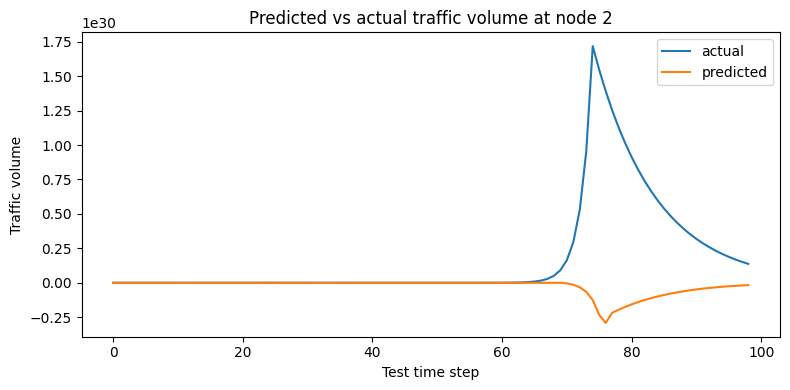

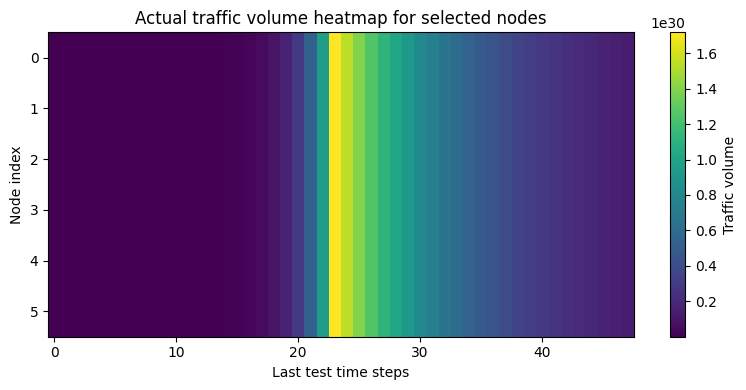

In [8]:
import matplotlib.pyplot as plt

with torch.no_grad():
    true_test = y_test.numpy() * y_scale
    pred_test = preds.numpy() * y_scale

# choose one node
node = 2
plt.figure(figsize=(8, 4))
plt.plot(true_test[:, node], label='actual')
plt.plot(pred_test[:, node], label='predicted')
plt.xlabel('Test time step')
plt.ylabel('Traffic volume')
plt.title('Predicted vs actual traffic volume at node 2')
plt.legend()
plt.tight_layout()
plt.show()

# heatmap for a subset of nodes over the last part of the test window
timesteps = 48
nodes_to_plot = [0, 1, 2, 3, 4, 5]

plt.figure(figsize=(8, 4))
subset = true_test[-timesteps:, nodes_to_plot].T
plt.imshow(subset, aspect='auto')
plt.colorbar(label='Traffic volume')
plt.yticks(range(len(nodes_to_plot)), nodes_to_plot)
plt.xlabel('Last test time steps')
plt.ylabel('Node index')
plt.title('Actual traffic volume heatmap for selected nodes')
plt.tight_layout()
plt.show()

## 8. Technical analysis

This prototype shows that a graph-based forecasting model can learn short-term congestion patterns on a synthetic road network. Even with a small simulated environment, the model captures meaningful structure by combining recent traffic history with network connectivity and contextual signals such as time of day and incident effects.

Key takeaways from the technical workflow:

1. The road system is naturally represented as a graph, where intersections are nodes and road segments define relationships between them.  
2. Simulated traffic patterns include rush-hour effects, spillover between neighboring intersections, and random disruption events, creating a more realistic forecasting problem.  
3. Node features combine lagged traffic values with time-based and incident-based signals, giving the model both temporal and contextual information.  
4. A graph neural network can propagate information across nearby intersections, allowing the forecast at one node to benefit from conditions elsewhere in the network.  
5. The model outperforms a naïve persistence baseline, suggesting that it is learning useful spatial-temporal behavior rather than simply copying the last observed value.

Overall, this notebook demonstrates a practical foundation for graph-based traffic prediction and provides a starting point for more advanced forecasting, optimization, and operational decision-support systems.


## 9. Business relevance and next steps

From an operational perspective, this project shows how AI could support transportation agencies, smart-city programs, or traffic operations centers with short-horizon congestion forecasting. A model like this could help identify which intersections are most likely to experience near-term pressure and support decisions around signal timing, operator attention, or dynamic traffic response.

Potential business and public-sector value includes:

- Earlier identification of congestion buildup  
- Better traffic signal and corridor management  
- More targeted deployment of field operators or control-room attention  
- Improved travel-time reliability and reduced delay  
- A foundation for future smart-city analytics tools  

The next stage would be to move from simulated data to real-world feeds such as DOT sensors, loop detectors, camera-based counts, or connected-vehicle data. From there, the model could be extended to multi-step forecasting, larger road networks, and interactive dashboards for planners and operations teams.

This project was originally developed as graduate coursework and is shared here as part of a professional portfolio to demonstrate applied machine learning, graph modeling, and business-focused AI problem solving.
